<a href="https://colab.research.google.com/github/Orliluq/automejora_recursiva/blob/main/automejora_recursiva_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Laboratorio de automejora recursiva

Este notebook construye una **simulación controlada** de un ciclo de automejora:

1. Partimos de una estrategia inicial.
2. El sistema genera variantes de esa estrategia.
3. Las evalúa contra un conjunto de validación.
4. Conserva la mejor versión.
5. Esa versión se convierte en el punto de partida de la siguiente generación.
6. Repite el proceso.

> **Importante:** esto no es una AGI ni demuestra que una IA real pueda mejorarse de forma autónoma. Es un experimento didáctico de **búsqueda + evaluación + selección iterativa** para visualizar el mecanismo abstracto de la automejora recursiva.

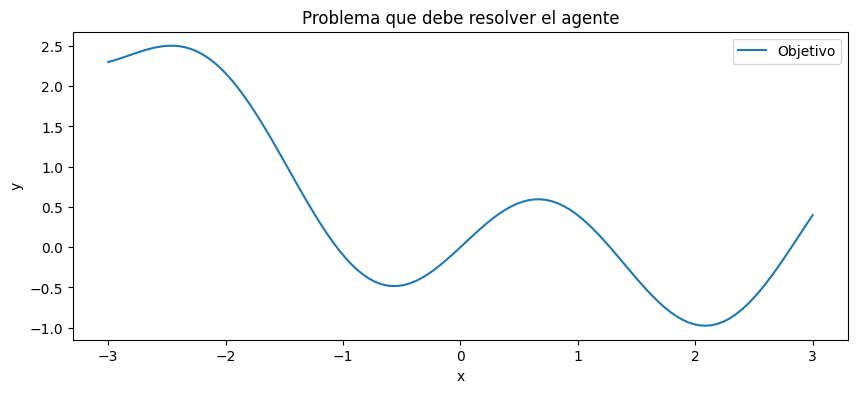

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

rng = np.random.default_rng(42)

# Función objetivo oculta que el sistema debe aproximar.
def objetivo(x):
    return 0.8 * np.sin(2.2 * x) + 0.15 * x**2 - 0.4 * x

x_train = np.linspace(-3, 3, 120)
y_train = objetivo(x_train)

# Conjunto separado para validar si la mejora generaliza.
x_val = np.linspace(-2.93, 2.93, 100)
y_val = objetivo(x_val)

plt.figure(figsize=(10, 4))
plt.plot(x_train, y_train, label="Objetivo")
plt.title("Problema que debe resolver el agente")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 1. La "mente" del agente: estructura + parámetros

Cada candidato contiene:

- una lista de **features**;
- un peso para cada feature;
- un sesgo.

La parte interesante es que el sistema puede modificar **parámetros y estructura**: puede cambiar pesos, añadir una feature o eliminar una que no aporte.

In [2]:
@dataclass
class Modelo:
    features: list
    pesos: np.ndarray
    bias: float

FEATURES = {
    "x": lambda x: x,
    "x2": lambda x: x**2,
    "x3": lambda x: x**3,
    "sin_x": lambda x: np.sin(x),
    "sin_2x": lambda x: np.sin(2*x),
    "cos_x": lambda x: np.cos(x),
}

def predecir(modelo, x):
    y = np.full_like(x, modelo.bias, dtype=float)
    for feature, peso in zip(modelo.features, modelo.pesos):
        y += peso * FEATURES[feature](x)
    return y

def mse(modelo, x, y):
    pred = predecir(modelo, x)
    return float(np.mean((pred - y) ** 2))

def describir(modelo):
    partes = [f"{modelo.bias:+.3f}"]
    for feature, peso in zip(modelo.features, modelo.pesos):
        partes.append(f"{peso:+.3f}·{feature}")
    return " ".join(partes)

modelo_inicial = Modelo(
    features=["x"],
    pesos=np.array([0.0]),
    bias=0.0,
)

print("Modelo inicial:", describir(modelo_inicial))
print("MSE inicial:", round(mse(modelo_inicial, x_val, y_val), 6))

Modelo inicial: +0.000 +0.000·x
MSE inicial: 1.394902


## 2. Cómo se genera una nueva versión

La función `mutar()` produce una candidata a partir de la versión actual.

Hay tres tipos de cambio:

**Paramétrico:** modifica ligeramente un peso o el sesgo.

**Estructural:** añade una feature nueva.

**Simplificación:** elimina una feature existente.

Luego el sistema compara las variantes y conserva la de menor error.

In [3]:
def clonar(modelo):
    return Modelo(
        features=modelo.features.copy(),
        pesos=modelo.pesos.copy(),
        bias=float(modelo.bias),
    )

def mutar(modelo, rng, prob_estructural=0.18):
    nuevo = clonar(modelo)

    # 1) Mutación paramétrica
    if len(nuevo.pesos) > 0:
        nuevo.pesos = nuevo.pesos + rng.normal(
            0, 0.15, size=len(nuevo.pesos)
        )
    nuevo.bias += float(rng.normal(0, 0.08))

    # 2) Mutación estructural: añadir una feature no usada
    if rng.random() < prob_estructural:
        disponibles = [f for f in FEATURES if f not in nuevo.features]
        if disponibles:
            feature = rng.choice(disponibles)
            nuevo.features.append(feature)
            nuevo.pesos = np.append(
                nuevo.pesos,
                rng.normal(0, 0.25)
            )

    # 3) Mutación estructural: eliminar una feature
    if len(nuevo.features) > 1 and rng.random() < 0.08:
        idx = int(rng.integers(len(nuevo.features)))
        nuevo.features.pop(idx)
        nuevo.pesos = np.delete(nuevo.pesos, idx)

    return nuevo

def generar_candidatos(modelo, n, rng):
    return [mutar(modelo, rng) for _ in range(n)]

def elegir_mejor(modelo_actual, candidatos):
    poblacion = [modelo_actual] + candidatos
    return min(
        poblacion,
        key=lambda m: mse(m, x_val, y_val)
    )

## 3. El ciclo recursivo

Aquí aparece el patrón central:

`modelo_n → generar variantes → evaluar → seleccionar → modelo_(n+1)`

La versión mejorada vuelve a entrar en **el mismo proceso**. Esa recurrencia es lo que estamos modelando como automejora recursiva.

In [4]:
modelo = modelo_inicial
historial = []

GENERACIONES = 60
CANDIDATOS_POR_GENERACION = 250

for generacion in range(GENERACIONES):
    antes = mse(modelo, x_val, y_val)

    candidatos = generar_candidatos(
        modelo,
        CANDIDATOS_POR_GENERACION,
        rng
    )

    mejor = elegir_mejor(modelo, candidatos)
    despues = mse(mejor, x_val, y_val)

    mejora = antes - despues
    modelo = mejor

    historial.append({
        "generacion": generacion,
        "mse": despues,
        "mejora": mejora,
        "features": modelo.features.copy(),
        "descripcion": describir(modelo),
    })

print("Modelo final:")
print(describir(modelo))
print("\nMSE final:", round(mse(modelo, x_val, y_val), 6))
print("Features finales:", modelo.features)

Modelo final:
+0.008 -0.114·x +0.143·x2 +1.009·sin_2x -0.622·sin_x

MSE final: 0.00304
Features finales: ['x', np.str_('x2'), np.str_('sin_2x'), np.str_('sin_x')]


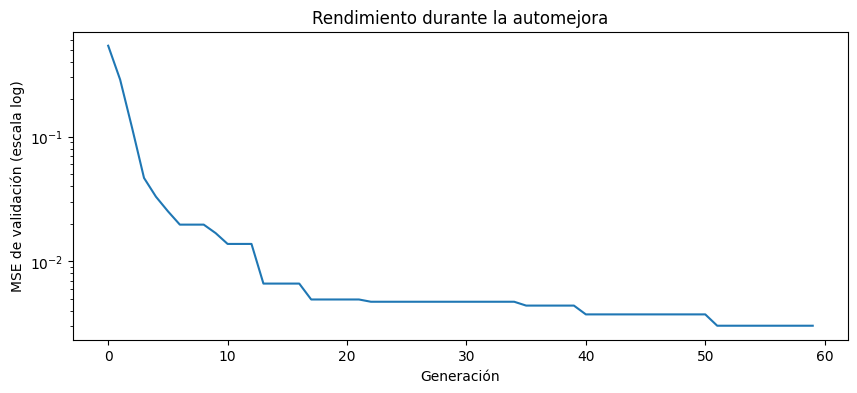

In [5]:
generaciones = [h["generacion"] for h in historial]
errores = [h["mse"] for h in historial]

plt.figure(figsize=(10, 4))
plt.plot(generaciones, errores)
plt.yscale("log")
plt.xlabel("Generación")
plt.ylabel("MSE de validación (escala log)")
plt.title("Rendimiento durante la automejora")
plt.show()

## 4. Ver el "linaje" de las versiones

Cada fila representa una generación. La estrategia de una generación sirve como punto de partida para producir la siguiente.

In [6]:
for h in historial[::5]:
    print(
        f"Gen {h['generacion']:02d} | "
        f"MSE={h['mse']:.6f} | "
        f"{h['descripcion']}"
    )

Gen 00 | MSE=0.538332 | -0.187 -0.222·x +0.187·x2
Gen 05 | MSE=0.025237 | +0.055 -0.319·x +0.151·x2 +0.759·sin_2x -0.143·sin_x
Gen 10 | MSE=0.013792 | +0.034 -0.213·x +0.117·x2 +0.986·sin_2x -0.443·sin_x -0.116·cos_x
Gen 15 | MSE=0.006626 | +0.012 -0.215·x +0.148·x2 +0.935·sin_2x -0.420·sin_x +0.028·cos_x
Gen 20 | MSE=0.004938 | +0.026 -0.136·x +0.148·x2 +0.926·sin_2x -0.555·sin_x
Gen 25 | MSE=0.004736 | +0.055 -0.157·x +0.147·x2 +0.933·sin_2x -0.549·sin_x
Gen 30 | MSE=0.004736 | +0.055 -0.157·x +0.147·x2 +0.933·sin_2x -0.549·sin_x
Gen 35 | MSE=0.004411 | +0.016 -0.140·x +0.139·x2 +1.009·sin_2x -0.623·sin_x
Gen 40 | MSE=0.003749 | -0.002 -0.107·x +0.152·x2 +0.971·sin_2x -0.617·sin_x
Gen 45 | MSE=0.003749 | -0.002 -0.107·x +0.152·x2 +0.971·sin_2x -0.617·sin_x
Gen 50 | MSE=0.003749 | -0.002 -0.107·x +0.152·x2 +0.971·sin_2x -0.617·sin_x
Gen 55 | MSE=0.003040 | +0.008 -0.114·x +0.143·x2 +1.009·sin_2x -0.622·sin_x


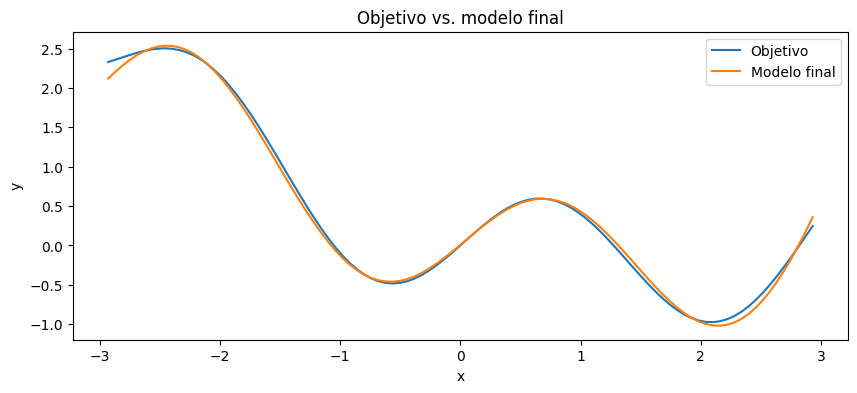

In [7]:
pred = predecir(modelo, x_val)

plt.figure(figsize=(10, 4))
plt.plot(x_val, y_val, label="Objetivo")
plt.plot(x_val, pred, label="Modelo final")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Objetivo vs. modelo final")
plt.legend()
plt.show()

## 5. ¿Por qué esto es "recursivo"?

```text
         ┌─────────────────────────┐
         │ estrategia actual       │
         └────────────┬────────────┘
                      ↓
              generar variantes
                      ↓
                evaluarlas
                      ↓
                elegir mejor
                      ↓
         ┌─────────────────────────┐
         │ nueva estrategia        │
         └────────────┬────────────┘
                      │
                      └──────────────↺
```

La automejora no necesita que el sistema tenga "intenciones". En este laboratorio basta con que pueda:

- proponer cambios sobre su estrategia;
- medir si esos cambios funcionan;
- conservar una mejora;
- repetir el proceso usando la nueva versión.

En sistemas reales, el salto desde este ejemplo a modelos avanzados es enorme. Aquí aislamos únicamente el mecanismo de **iteración + evaluación + selección**.

## 🧪 Experimentos para ampliar el laboratorio

**A. Más candidatos:** aumenta `CANDIDATOS_POR_GENERACION` y observa cómo cambia la velocidad de mejora.

**B. Más cambios estructurales:** aumenta `prob_estructural` y observa cómo cambia la complejidad de la solución.

**C. Sobreajuste:** cambia la selección para usar `x_train, y_train` en lugar de validación y compara el resultado.

**D. Presupuesto:** limita el número total de evaluaciones. Esto introduce una idea crucial: la automejora también está limitada por cómputo, memoria, tiempo y costo.

## ✅ Conclusión para explicar el ejercicio

**No estamos demostrando que una IA vaya a destruir a la humanidad.**

Estamos demostrando algo mucho más concreto: un sistema puede producir una nueva versión de su propia estrategia, medir si es mejor y repetir el proceso.

Si cada generación dispone de mejores mecanismos para producir la siguiente, aparece un **bucle de automejora**.

La pregunta de seguridad comienza después:

> **¿Qué ocurre cuando el sistema que estamos mejorando es muchísimo más capaz, puede actuar en el mundo real y sus mecanismos de evaluación dejan de ser suficientes?**